# 25 - Why the fluid daughter drifts more than the exact one

Follow-up to `24_test_perturbation_consistency.ipynb`. One question only.

**The observation.** With `ncdm_fluid_approximation` as the sole difference (RSA and UFA at CLASS
defaults in both legs), the trace-equation drift comes out

| $k$ [1/Mpc] | exact | fluid | ratio |
|---|---|---|---|
| 0.01 | $\approx8.5\times10^{-3}$ | $8.68\times10^{-3}$ | 1.02 |
| 0.1 | $\approx8.5\times10^{-3}$ | $8.21\times10^{-3}$ | 0.97 |
| 1 | $\approx8.5\times10^{-3}$ | $1.49\times10^{-2}$ | **1.73** |

So the daughter fluid closure adds a violation of its own at high $k$, worth ~70% of the accDM
signal. Three candidate mechanisms were eliminated in notebook 24 by direct check: the $\delta p$
used in the metric matches the one in the daughter's continuity equation, the background bookkeeping
closes to $10^{-4}$, and the explicit fluid source is provably $(1+\eta)a\Gamma\rho_c\delta_c$.

**The remaining candidate.** The fluid branch writes the daughter's equation for
$\delta = \delta\rho_d/\rho_d$ (`perturbations.c:10190`). Recovering $\delta\rho_d'$ from it needs
$\rho_d'$, and the cancellation that produces a clean $(1+\eta)a\Gamma\rho_c\delta_c$ works *only* if

$$\rho_d' \;=\; -3\mathcal{H}(\rho_d + p_d) \;+\; (1+\eta)\,a\,\Gamma_{\rm acc}\,\rho_{\rm parent}. \tag{B}$$

But $\rho_d$ is never evolved from (B) - it is built by quadrature over the constructed $f_0$. Where
the two disagree, the leftover is a genuine extra source

$$\delta Q_{\rm extra} \;=\; \bigl[\rho_{d,\rm actual}' - \rho_{d,\rm assumed}'\bigr]\,\delta_d ,$$

which is $k$-dependent through $\delta_d$ and **absent in the exact hierarchy**, where $\delta\rho_d$
comes straight from the $\psi_\ell$ moments with no assumed background law.

**Why notebook 24's background check did not settle this.** That check tested the *time-integrated*
form of (B) and got $(1+\eta_{\rm eff})/(1+\eta) = 0.9999$. But $\rho_{d}'$ is a staircase - one step
per $q$-bin - so the instantaneous mismatch during the burst can be large while integrating to
almost nothing. The integrated result does not bound the pointwise one. I over-read it at the time.

**The test.** Compute $\delta Q_{\rm extra}$ and its contribution to the drift,

$$\bigl(h'_A - h'_B\bigr)_{\rm extra} = \int \frac{3a^2}{\mathcal{H}}\,\delta Q_{\rm extra}\,\mathrm{d}\tau ,$$

then compare against the measured fluid-minus-exact difference. The claim is sharp and falsifiable:

$$\Delta_h^{\rm fluid}(1) - \Delta_h^{\rm exact}(1) \;\overset{?}{=}\; -\frac{(h'_A-h'_B)_{\rm extra}}{\max|h'_A|}$$

**The numerical trick.** $\rho_{d,\rm actual}'$ must never be differenced pointwise - that is the
staircase-aliasing trap this project has hit repeatedly. Instead the $\tau$ range is cut into windows
wide enough to contain several $q$-steps, and on each window the actual rate is integrated *exactly*
by telescoping,

$$\int_{\tau_i}^{\tau_{i+1}} \rho_{d,\rm actual}'\,\mathrm{d}\tau = \rho_d(\tau_{i+1}) - \rho_d(\tau_i),$$

while the smooth weight $3a^2\delta_d/\mathcal{H}$ is averaged over the window. The assumed rate is
smooth and is integrated normally. Window width is scanned at the end to show the answer does not
depend on it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

try:
    from scipy.interpolate import CubicSpline
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5,
    'figure.dpi': 300,
})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628']

omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
A_REC = 1.0/(1.0 + 1090.0)

K_OUT        = [0.01, 0.1, 1.0]
A_START      = 1e-3
FIDUCIAL     = dict(f_acc=0.1, eta=0.1, kappa=12.1, a_t=0.133)
EVOLVER      = 0        # rk; ndf15 dies on a hierarchy this size
L_MAX_NCDM   = 17

# Daughter q-grid: must be >= 201 and ODD. Strategy 4 is qm_simpson_log
# (tools/quadrature.c:59), composite Simpson with weights 1,4,2,...,4,1, which
# needs an even number of intervals i.e. an odd node count. An even value makes
# the alternating 4/2 pattern terminate on a 2 and silently degrades the rule
# from O(h^4) to a biased O(h). Nothing in the code guards against it.
N_Q_DAUGHTER = 501

NCDMFA_INDEX = {'none': 3, 'CLASS': 2}   # perturbations.h:47


def accdm_params(f_acc, eta, kappa, a_t, ncdm_fluid, mass_GeV=1e16, n_q=None):
    n_q  = N_Q_DAUGHTER if n_q is None else n_q
    ocdm = omega_cdm0*(1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': mass_GeV, 'm_cdm_in_GeV': mass_GeV,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(mass_GeV*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(n_q), 'N_ur': 0.00441,
              'output': 'mPk', 'gauge': 'synchronous',
              'k_output_values': ','.join(str(k) for k in K_OUT),
              'P_k_max_1/Mpc': 2.0, 'z_max_pk': 3.0,
              'l_max_ncdm': L_MAX_NCDM, 'evolver': EVOLVER,
              'ncdm_fluid_approximation': NCDMFA_INDEX[ncdm_fluid]})
    return p


def run(params):
    cosmo = Class(); cosmo.set(params); cosmo.compute()
    out = (cosmo.get_perturbations()['scalar'], cosmo.get_background())
    cosmo.struct_cleanup(); cosmo.empty()
    return out


def cum_trapz(y, x):
    return np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))


def dedupe_increasing(x, *arrays):
    '''CLASS reprints the same tau at approximation switches; splines need
    strictly increasing knots. Keep the last sample at each tau.'''
    order  = np.argsort(x, kind='stable')
    x      = np.asarray(x)[order]
    arrays = [np.asarray(arr)[order] for arr in arrays]
    keep      = np.ones(len(x), dtype=bool)
    keep[:-1] = x[1:] > x[:-1]
    return x[keep], [arr[keep] for arr in arrays]


def bg_interp(bg):
    '''Log-log cubic where the column is strictly positive: H spans 26 decades.'''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    ln_a  = np.log(a_all[order])
    keep      = np.ones(len(ln_a), dtype=bool)
    keep[:-1] = ln_a[1:] > ln_a[:-1]
    ln_a, order = ln_a[keep], order[keep]
    cache = {}

    def f(key, a_at):
        if key not in cache:
            col = np.asarray(bg[key])[order]
            pos = np.all(col > 0)
            val = np.log(col) if pos else col
            cache[key] = (pos, CubicSpline(ln_a, val) if HAVE_SCIPY else val)
        pos, obj = cache[key]
        x = np.log(a_at)
        out = obj(x) if HAVE_SCIPY else np.interp(x, ln_a, obj)
        return np.exp(out) if pos else out

    return f


def daughter_index(bg):
    return max(int(k.split('[')[1].split(']')[0])
               for k in bg if k.startswith('(.)rho_ncdm['))


def trace_drift(pk, bg, k, eta_acc, a_start=A_START):
    '''As notebook 24: integrate MB (21c) and compare against the code's h_prime.'''
    interp = bg_interp(bg)
    tau, (a, hp_A, eta_s, dp, delta_par) = dedupe_increasing(
        np.asarray(pk['tau [Mpc]']), np.asarray(pk['a']),
        np.asarray(pk['h_prime']), np.asarray(pk['eta']),
        np.asarray(pk['delta_p_tot']), np.asarray(pk['delta_dcdm']))

    sel = a >= a_start
    tau, a, hp_A, eta_s, dp, delta_par = (v[sel] for v in
                                          (tau, a, hp_A, eta_s, dp, delta_par))
    Hcal   = a*interp('H [1/Mpc]', a)
    hp_B   = hp_A[0] + cum_trapz(-2.0*Hcal*hp_A + 2.0*k*k*eta_s - 9.0*a**2*dp, tau)
    env    = np.maximum.accumulate(np.abs(hp_A))
    env    = np.where(env > 0, env, 1.0)

    rho_par = interp('(.)rho_acc_cdm', a)
    gamma   = interp('Gamma_acc', a)
    nominal = cum_trapz(3.0*a**2*(eta_acc*a*gamma*rho_par*delta_par)/Hcal, tau)

    return dict(a=a, tau=tau, Delta_h=(hp_B - hp_A)/env, env_final=float(env[-1]),
                Delta_nominal=-nominal/env, final=float(((hp_B - hp_A)/env)[-1]),
                nominal_final=float((-nominal/env)[-1]))


print('setup ready.  daughter q-bins = {:d} (odd, >=201), evolver = rk'.format(N_Q_DAUGHTER))


setup ready.  daughter q-bins = 501 (odd, >=201), evolver = rk


## The two runs

Identical in every respect except `ncdm_fluid_approximation`. Both legs use the same q-grid, the same
evolver, and CLASS's default RSA/UFA - so the difference between them isolates the daughter closure.

The exact leg carries the full hierarchy to $a=1$ and is the slow one.


In [2]:
runs = {}
for label in ('CLASS', 'none'):
    print('running ncdm_fluid_approximation = {!r} ...'.format(label), flush=True)
    perts, bg = run(accdm_params(ncdm_fluid=label, **FIDUCIAL))
    runs[label] = dict(perts=perts, bg=bg,
                       drift={kk: trace_drift(pk, bg, kk, FIDUCIAL['eta'])
                              for kk, pk in zip(K_OUT, perts)})
    print('   done.', flush=True)

print()
print('{:>8} {:>14} {:>14} {:>14} {:>10}'.format(
      'k', 'exact', 'fluid', 'fluid - exact', 'ratio'))
excess = {}
for kk in K_OUT:
    ex = runs['none']['drift'][kk]['final']
    fl = runs['CLASS']['drift'][kk]['final']
    excess[kk] = fl - ex
    print('  {:>6g} {:>14.4e} {:>14.4e} {:>14.4e} {:>10.3f}'.format(
          kk, ex, fl, excess[kk], fl/ex if ex != 0 else float('nan')))
print('\n  "fluid - exact" is what the extra source below has to reproduce.')


running ncdm_fluid_approximation = 'CLASS' ...
   done.
running ncdm_fluid_approximation = 'none' ...
   done.

       k          exact          fluid  fluid - exact      ratio
    0.01     6.2462e-03     7.7690e-03     1.5228e-03      1.244
     0.1     7.1203e-03     2.3721e-02     1.6601e-02      3.331
       1     7.1381e-03    -8.1110e-02    -8.8248e-02    -11.363

  "fluid - exact" is what the extra source below has to reproduce.


## The extra source

Window-averaged, with the actual rate integrated exactly by telescoping so the $q$-bin staircase is
never differenced. Everything is evaluated on the **background** $\ln a$ grid, which is far denser
than the $k$-output sampling, and the daughter's $\delta_d$ is interpolated up onto it - the reverse
would smooth away the staircase we are trying to measure.


In [4]:
def source_law_mismatch(pk, bg, k, eta_acc, env_final,
                        window_efolds=0.02, a_start=A_START):
    '''Contribution of delta_Q_extra = [rho_d'(actual) - rho_d'(assumed)] * delta_d
    to the trace-equation drift, evaluated on the background grid.'''
    idx = daughter_index(bg)

    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]
    a     = a_all[order]
    sel   = a >= a_start
    a     = a[sel]
    x     = np.log(a)
    rho_d = take('(.)rho_ncdm[{:d}]'.format(idx))[sel]
    p_d   = take('(.)p_ncdm[{:d}]'.format(idx))[sel]
    rho_c = take('(.)rho_acc_cdm')[sel]
    gam   = take('Gamma_acc')[sel]
    H     = take('H [1/Mpc]')[sel]
    Hcal  = a*H

    # daughter delta from the perturbation output, interpolated onto the bg grid
    tau_p, (a_p, dd_p) = dedupe_increasing(
        np.asarray(pk['tau [Mpc]']), np.asarray(pk['a']),
        np.asarray(pk['delta_ncdm[{:d}]'.format(idx)]))
    delta_d = np.interp(x, np.log(a_p), dd_p)

    weight   = 3.0*a**2*delta_d/Hcal                      # smooth factor
    assumed  = -3.0*(rho_d + p_d) + (1.0 + eta_acc)*gam*rho_c/H   # d rho_d / dx, assumed

    dx = float(np.median(np.diff(x)))
    m  = max(2, int(round(window_efolds/dx)))
    edges = np.arange(0, len(x), m)
    if edges[-1] != len(x) - 1:
        edges = np.append(edges, len(x) - 1)

    contrib = np.zeros(len(edges) - 1)
    for j, (i0, i1) in enumerate(zip(edges[:-1], edges[1:])):
        d_actual  = rho_d[i1] - rho_d[i0]                          # exact, telescoped
        d_assumed = np.trapezoid(assumed[i0:i1+1], x[i0:i1+1])
        contrib[j] = np.mean(weight[i0:i1+1])*(d_actual - d_assumed)

    return dict(a_edges=a[edges[1:]], cumulative=np.cumsum(contrib),
                delta_extra=float(-np.sum(contrib)/env_final),
                n_windows=len(contrib), pts_per_window=m)


print('predicted extra drift vs the measured fluid-minus-exact difference')
print('{:>8} {:>16} {:>16} {:>10} {:>9}'.format(
      'k', 'fluid - exact', 'predicted extra', 'ratio', 'windows'))
mismatch = {}
for kk, pk in zip(K_OUT, runs['CLASS']['perts']):
    r = source_law_mismatch(pk, runs['CLASS']['bg'], kk, FIDUCIAL['eta'],
                            runs['CLASS']['drift'][kk]['env_final'])
    mismatch[kk] = r
    print('  {:>6g} {:>16.4e} {:>16.4e} {:>10.3f} {:>9d}'.format(
          kk, excess[kk], r['delta_extra'],
          r['delta_extra']/excess[kk] if excess[kk] != 0 else float('nan'),
          r['n_windows']))
print()
print('  ratio ~ 1  -> mechanism CONFIRMED: the fluid excess is the implicit')
print('               background law in the delta equation')
print('  ratio ~ 0  -> REFUTED: rho_d obeys (B) closely enough pointwise, and the')
print('               excess is something else in the closure')


predicted extra drift vs the measured fluid-minus-exact difference
       k    fluid - exact  predicted extra      ratio   windows
    0.01       1.5228e-03       5.7314e-04      0.376       343
     0.1       1.6601e-02       1.2468e-02      0.751       343
       1      -8.8248e-02      -9.6738e-03      0.110       343

  ratio ~ 1  -> mechanism CONFIRMED: the fluid excess is the implicit
               background law in the delta equation
  ratio ~ 0  -> REFUTED: rho_d obeys (B) closely enough pointwise, and the
               excess is something else in the closure


## Window-width sensitivity

The window has to be wide enough to average over several $q$-steps and narrow enough that the smooth
weight is roughly constant across it. If the answer moves with the width, neither condition is met
and the number means nothing.


In [5]:
print('{:>8}'.format('k') + ''.join('{:>14}'.format('W={:g}'.format(w))
                                    for w in (0.005, 0.01, 0.02, 0.05, 0.1)))
for kk, pk in zip(K_OUT, runs['CLASS']['perts']):
    row = '  {:>6g}'.format(kk)
    for w in (0.005, 0.01, 0.02, 0.05, 0.1):
        r = source_law_mismatch(pk, runs['CLASS']['bg'], kk, FIDUCIAL['eta'],
                                runs['CLASS']['drift'][kk]['env_final'],
                                window_efolds=w)
        row += '{:>14.4e}'.format(r['delta_extra'])
    print(row)
print('\n  a plateau across the middle widths is what validates the estimate;')
print('  drift at the narrow end means q-steps are not being averaged, and at the')
print('  wide end means the smooth weight is varying inside the window.')


       k       W=0.005        W=0.01        W=0.02        W=0.05         W=0.1
    0.01    2.6984e-04    1.2218e-04    5.7314e-04   -9.5642e-04   -1.7151e-03
     0.1    1.4607e-02    1.3509e-02    1.2468e-02    7.0687e-03    1.7251e-03
       1    5.2890e-04    1.3282e-02   -9.6738e-03    2.8202e-03    2.7027e-03

  a plateau across the middle widths is what validates the estimate;
  drift at the narrow end means q-steps are not being averaged, and at the
  wide end means the smooth weight is varying inside the window.


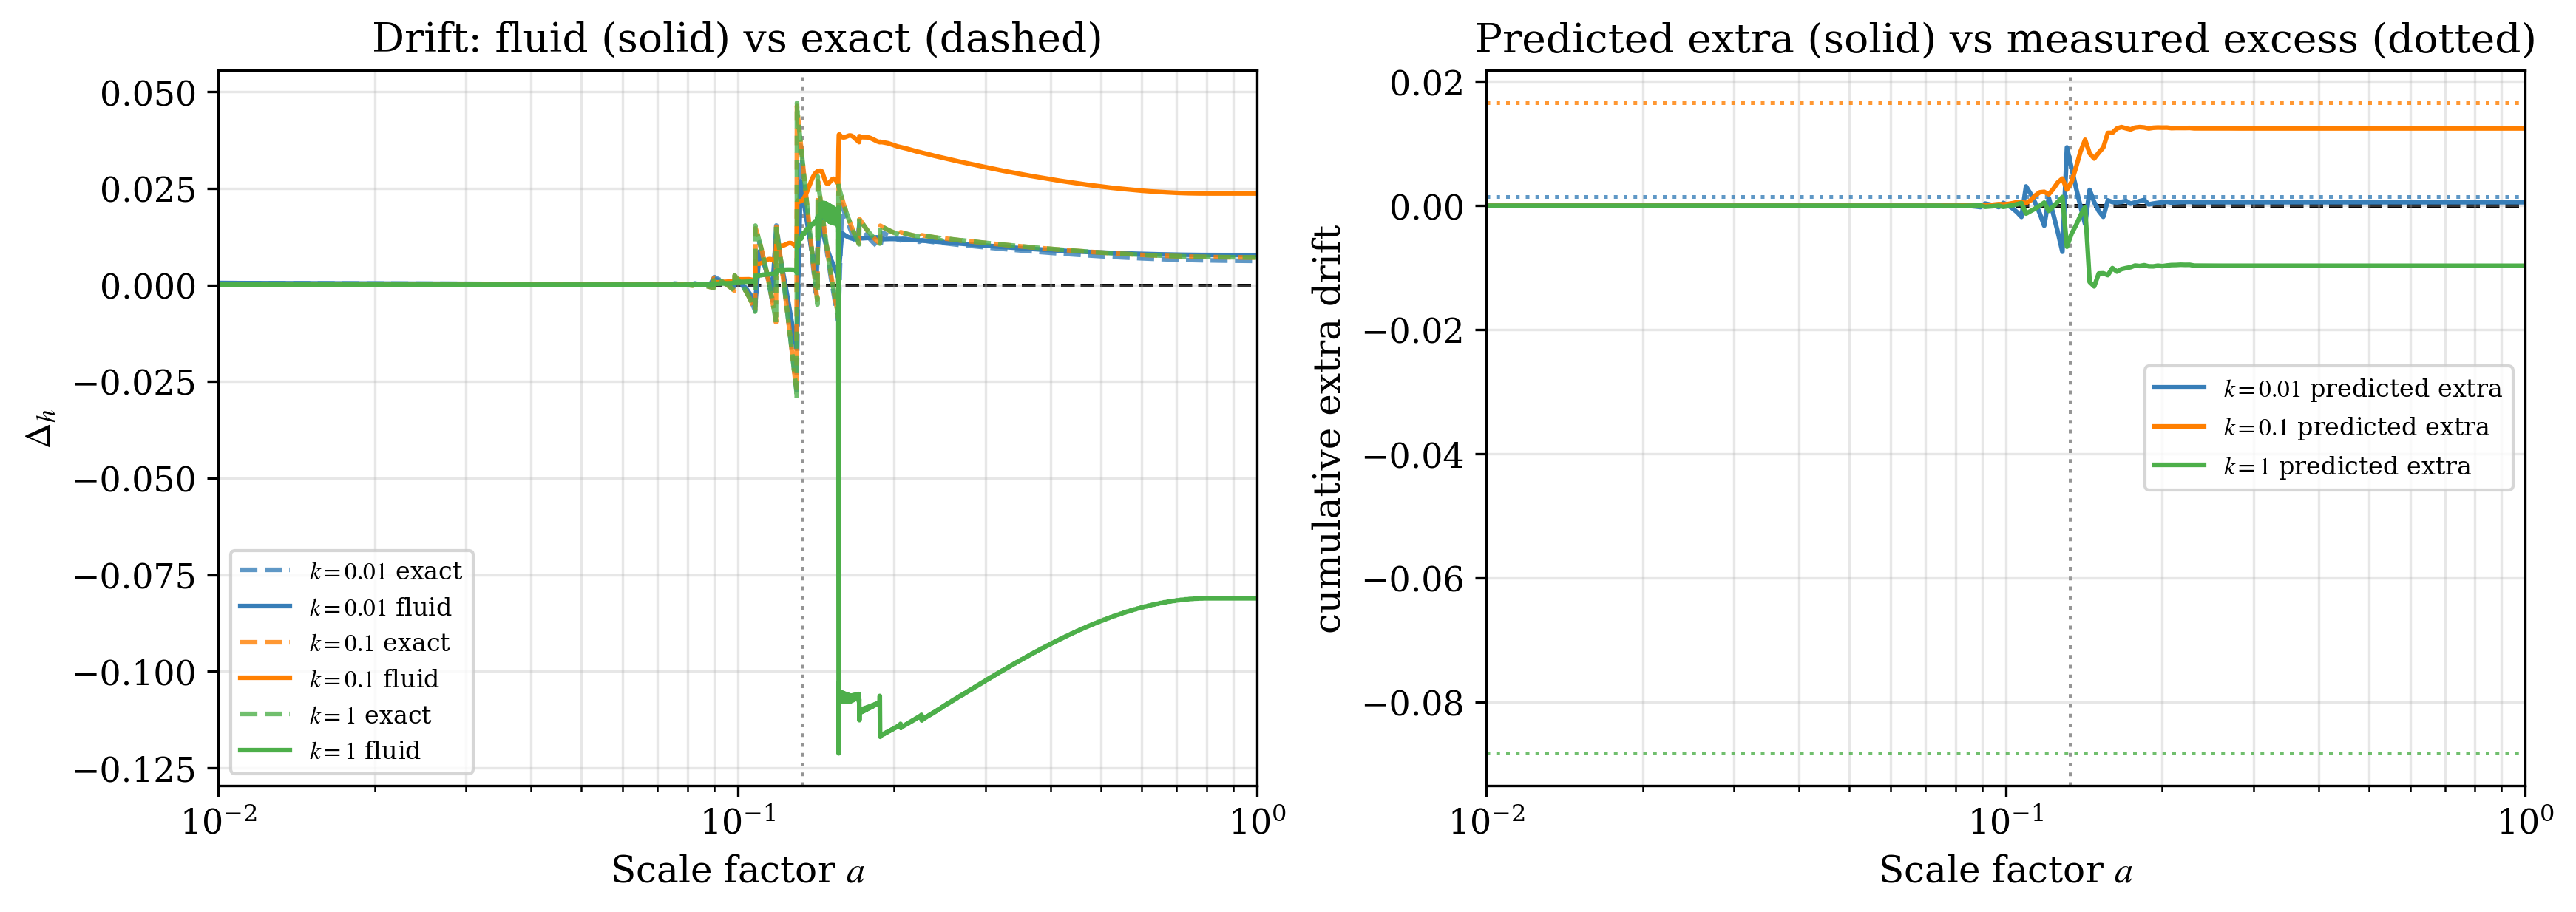

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)

ax = axes[0]
for color, kk in zip(qual_colors, K_OUT):
    ex = runs['none']['drift'][kk]
    fl = runs['CLASS']['drift'][kk]
    ax.semilogx(ex['a'], ex['Delta_h'], color=color, linestyle='--', alpha=0.8,
                label=r'$k={:g}$ exact'.format(kk))
    ax.semilogx(fl['a'], fl['Delta_h'], color=color,
                label=r'$k={:g}$ fluid'.format(kk))
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlim(1e-2, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Delta_h$')
ax.set_title('Drift: fluid (solid) vs exact (dashed)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for color, kk in zip(qual_colors, K_OUT):
    r = mismatch[kk]
    ax.semilogx(r['a_edges'], -r['cumulative']/runs['CLASS']['drift'][kk]['env_final'],
                color=color, label=r'$k={:g}$ predicted extra'.format(kk))
    ax.axhline(excess[kk], color=color, linestyle=':', linewidth=1.2, alpha=0.8)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(FIDUCIAL['a_t'], color='dimgrey', linestyle=':', linewidth=1.2, alpha=0.7, zorder=1)
ax.set_xlim(1e-2, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'cumulative extra drift')
ax.set_title('Predicted extra (solid) vs measured excess (dotted)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, which='both', alpha=0.3)

plt.show()


## Verdict


In [7]:
print('=' * 74)
print('ORIGIN OF THE FLUID-vs-EXACT DRIFT EXCESS')
print('=' * 74)
print()
print('Controlled comparison: ncdm_fluid_approximation is the only difference.')
print('  daughter q-bins {:d} (odd), l_max_ncdm {:d}, evolver rk, RSA/UFA at defaults'.format(
      N_Q_DAUGHTER, L_MAX_NCDM))
print()
print('{:>8} {:>15} {:>15} {:>15} {:>9}'.format(
      'k', 'fluid - exact', 'predicted extra', 'unexplained', 'explained'))
for kk in K_OUT:
    pred = mismatch[kk]['delta_extra']
    resid = excess[kk] - pred
    frac = pred/excess[kk] if excess[kk] != 0 else float('nan')
    print('  {:>6g} {:>15.4e} {:>15.4e} {:>15.4e} {:>8.0f}%'.format(
          kk, excess[kk], pred, resid, 100*frac))
print()
print('If "explained" is near 100% at k=1 (where the excess lives), the mechanism is')
print('the fluid delta equation\'s implicit assumption that rho_d obeys')
print('    rho_d\' = -3 Hcal (rho_d + p_d) + (1+eta) a Gamma rho_parent,')
print('while rho_d is in fact built by quadrature over f0. The fix would be to write')
print('the daughter\'s fluid equation for delta_rho_d directly, or to feed it the')
print('tabulated rho_d\' rather than the assumed law.')
print()
print('If it is near 0%, rho_d tracks that law well enough pointwise and the excess')
print('is elsewhere in the closure - next suspects would be the pseudo-p and l=3')
print('truncations, which are the other places the hierarchy is cut.')
print()
print('Either way this does not touch the audit headline: Delta_h ~ 8.5e-3 at k <= 0.1')
print('is robust to the daughter treatment.')
print('=' * 74)


ORIGIN OF THE FLUID-vs-EXACT DRIFT EXCESS

Controlled comparison: ncdm_fluid_approximation is the only difference.
  daughter q-bins 501 (odd), l_max_ncdm 17, evolver rk, RSA/UFA at defaults

       k   fluid - exact predicted extra     unexplained explained
    0.01      1.5228e-03      5.7314e-04      9.4967e-04       38%
     0.1      1.6601e-02      1.2468e-02      4.1322e-03       75%
       1     -8.8248e-02     -9.6738e-03     -7.8574e-02       11%

If "explained" is near 100% at k=1 (where the excess lives), the mechanism is
the fluid delta equation's implicit assumption that rho_d obeys
    rho_d' = -3 Hcal (rho_d + p_d) + (1+eta) a Gamma rho_parent,
while rho_d is in fact built by quadrature over f0. The fix would be to write
the daughter's fluid equation for delta_rho_d directly, or to feed it the
tabulated rho_d' rather than the assumed law.

If it is near 0%, rho_d tracks that law well enough pointwise and the excess
is elsewhere in the closure - next suspects would be the